# Offshore Platform Energy Integration

This notebook demonstrates how to model and optimize the power supply for an offshore
oil & gas platform using NeqSim's energy integration classes:

- **WindFarm** — offshore wind generation with power curves
- **BatteryStorage** — energy buffer for intermittent wind
- **Gas Turbine** — backup for calm wind periods
- **OffshoreEnergySystem** — dispatch optimizer with CO2 tracking

The analysis compares different energy scenarios:
1. 100% gas turbine (baseline)
2. Wind + gas turbine
3. Wind + battery + gas turbine

Key outputs: CO2 emissions, fuel savings, renewable fraction, and hourly dispatch profiles.

In [1]:
# NeqSim setup - dual-boot (devtools for local dev, pip for Colab)
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.6.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
# Import required classes and libraries
import numpy as np
import matplotlib.pyplot as plt
import jpype

if NEQSIM_MODE == "devtools":
    WindFarm = jpype.JClass("neqsim.process.equipment.powergeneration.WindFarm")
    OffshoreEnergySystem = jpype.JClass("neqsim.process.equipment.powergeneration.OffshoreEnergySystem")
    BatteryStorage = jpype.JClass("neqsim.process.equipment.battery.BatteryStorage")
else:
    from neqsim import jneqsim
    WindFarm = jneqsim.process.equipment.powergeneration.WindFarm
    OffshoreEnergySystem = jneqsim.process.equipment.powergeneration.OffshoreEnergySystem
    BatteryStorage = jneqsim.process.equipment.battery.BatteryStorage

print("All classes imported successfully")

All classes imported successfully


## 1. Platform Configuration

We model a typical North Sea oil platform needing **50 MW** continuous electrical power.
The wind farm has 5 turbines (75 MW rated) connected via subsea cable.

In [3]:
# === Wind Farm ===
farm = WindFarm("Platform Wind Farm", 5)
farm.setRatedPowerPerTurbine(15.0e6)  # 15 MW each
farm.setRotorDiameter(236.0)          # m
farm.setHubHeight(135.0)              # m
farm.setCutInSpeed(3.0)               # m/s
farm.setRatedSpeed(12.0)              # m/s
farm.setCutOutSpeed(25.0)             # m/s
farm.setWakeLossFactor(0.08)          # 8% wake loss (fewer turbines)
farm.setAvailabilityFactor(0.95)      # 95%
farm.setElectricalLossFactor(0.02)    # 2% cable losses
farm.setAirTemperature(10.0)          # deg C

# === Battery ===
# 200 MWh capacity (= 4 hours of full demand)
battery_capacity_j = 200.0e6 * 3600.0  # 200 MWh in Joules
battery = BatteryStorage("Li-ion Battery", battery_capacity_j)
battery.setStateOfCharge(battery_capacity_j * 0.5)  # Start at 50%

# === Gas Turbine ===
gt_capacity_w = 50.0e6  # 50 MW
gt_efficiency = 0.35     # 35% LHV
gt_min_load = 0.30       # 30% minimum

# === Platform demand ===
platform_demand_w = 50.0e6  # 50 MW constant

print("=== Platform Energy Configuration ===")
print(f"Platform demand: {platform_demand_w/1e6:.0f} MW")
print(f"Wind farm capacity: {farm.getTotalRatedPower()/1e6:.0f} MW ({farm.getNumberOfTurbines()} turbines)")
print(f"Battery capacity: {battery_capacity_j/3.6e9:.0f} MWh")
print(f"Gas turbine capacity: {gt_capacity_w/1e6:.0f} MW")
print(f"Gas turbine efficiency: {gt_efficiency*100:.0f}%")

=== Platform Energy Configuration ===
Platform demand: 50 MW
Wind farm capacity: 75 MW (5 turbines)
Battery capacity: 200 MWh
Gas turbine capacity: 50 MW
Gas turbine efficiency: 35%


## 2. Generate Synthetic Wind Data

Create a realistic 168-hour (1 week) wind speed profile using a North Sea Weibull
distribution with diurnal variations and weather front events.

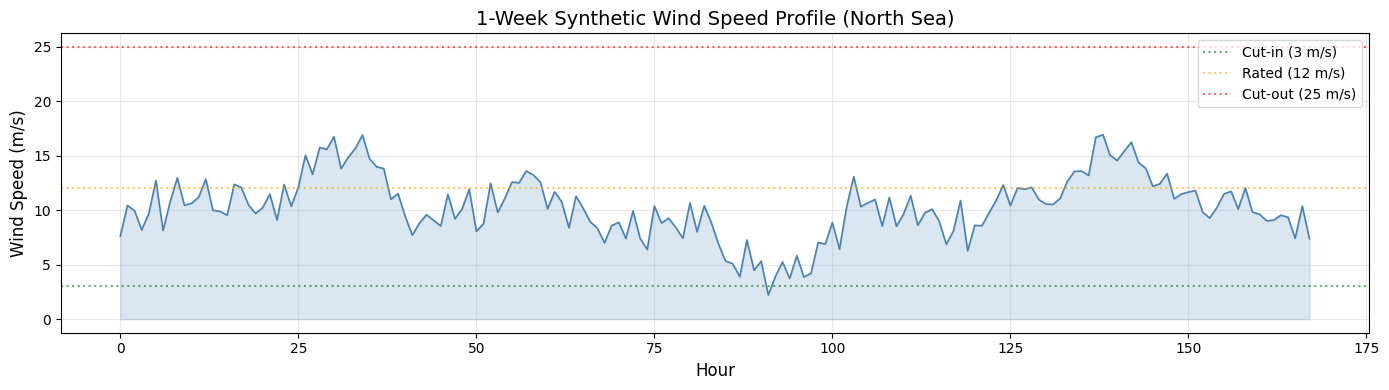

Mean wind: 10.3 m/s
Max wind: 16.9 m/s
Min wind: 2.2 m/s


In [4]:
np.random.seed(123)
hours = 168  # 1 week
t = np.arange(hours)

# Base wind from Weibull-like distribution
base_wind = 10.0 + 1.5 * np.sin(2 * np.pi * t / 24 - np.pi/4)  # Diurnal

# Weather fronts (3 events)
front1 = 6.0 * np.exp(-0.5 * ((t - 30) / 5)**2)    # Storm at hour 30
front2 = -5.0 * np.exp(-0.5 * ((t - 90) / 8)**2)    # Calm at hour 90
front3 = 7.0 * np.exp(-0.5 * ((t - 140) / 4)**2)    # Storm at hour 140

noise = np.random.normal(0, 1.2, hours)
wind_speeds = np.clip(base_wind + front1 + front2 + front3 + noise, 0, 28)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, wind_speeds, 'steelblue', linewidth=1.2)
ax.fill_between(t, wind_speeds, alpha=0.2, color='steelblue')
ax.axhline(y=3.0, color='green', linestyle=':', alpha=0.6, label='Cut-in (3 m/s)')
ax.axhline(y=12.0, color='orange', linestyle=':', alpha=0.6, label='Rated (12 m/s)')
ax.axhline(y=25.0, color='red', linestyle=':', alpha=0.6, label='Cut-out (25 m/s)')
ax.set_xlabel('Hour', fontsize=12)
ax.set_ylabel('Wind Speed (m/s)', fontsize=12)
ax.set_title('1-Week Synthetic Wind Speed Profile (North Sea)', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean wind: {np.mean(wind_speeds):.1f} m/s")
print(f"Max wind: {np.max(wind_speeds):.1f} m/s")
print(f"Min wind: {np.min(wind_speeds):.1f} m/s")

## 3. Scenario A: 100% Gas Turbine (Baseline)

All platform power is supplied by gas turbines — the conventional case.

In [5]:
# Baseline: 100% gas turbine, no wind
co2_factor = 0.55  # kg CO2 per kWh
demand_kw = platform_demand_w / 1000.0

baseline_co2_hr = demand_kw * co2_factor  # kg CO2/hr
baseline_co2_year = baseline_co2_hr * 8760 / 1000.0  # tonnes/year
baseline_fuel_hr = platform_demand_w / (gt_efficiency * 48.0e6) * 3600.0  # kg/hr (LHV=48 MJ/kg)
baseline_fuel_year = baseline_fuel_hr * 8760 / 1000.0  # tonnes/year

print("=== Scenario A: 100% Gas Turbine (Baseline) ===")
print(f"Platform demand: {platform_demand_w/1e6:.0f} MW")
print(f"CO2 emissions: {baseline_co2_hr:.0f} kg/hr")
print(f"CO2 emissions: {baseline_co2_year:.0f} tonnes/year")
print(f"Fuel consumption: {baseline_fuel_hr:.0f} kg/hr")
print(f"Fuel consumption: {baseline_fuel_year:.0f} tonnes/year")
print(f"Renewable fraction: 0%")

=== Scenario A: 100% Gas Turbine (Baseline) ===
Platform demand: 50 MW
CO2 emissions: 27500 kg/hr
CO2 emissions: 240900 tonnes/year
Fuel consumption: 10714 kg/hr
Fuel consumption: 93857 tonnes/year
Renewable fraction: 0%


## 4. Scenario B: Wind + Gas Turbine (No Battery)

Run the `OffshoreEnergySystem` without battery — wind displaces gas directly.

In [6]:
# Scenario B: Wind + GT, no battery
system_b = OffshoreEnergySystem("Platform Energy B")
system_b.setWindFarm(farm)
system_b.setGasTurbineCapacity(gt_capacity_w)
system_b.setGasTurbineEfficiency(gt_efficiency)
system_b.setGasTurbineMinLoad(gt_min_load)
system_b.setTotalPowerDemand(platform_demand_w)
system_b.setCO2EmissionFactor(co2_factor)
system_b.setTimeStepHours(1.0)

# Run hourly dispatch
wind_java_b = jpype.JArray(jpype.JDouble)(len(wind_speeds))
for i, v in enumerate(wind_speeds):
    wind_java_b[i] = float(v)
system_b.runHourlyDispatch(wind_java_b)

# Extract dispatch history
history_b = system_b.getDispatchHistory()
wind_del_b = np.array([float(h.get("windDelivered_MW")) for h in history_b])
gt_del_b = np.array([float(h.get("gasTurbineDelivered_MW")) for h in history_b])
curtailed_b = np.array([float(h.get("curtailed_MW")) for h in history_b])
co2_b = np.array([float(h.get("co2_kg_hr")) for h in history_b])

wind_frac_b = np.sum(wind_del_b) / (np.sum(wind_del_b) + np.sum(gt_del_b)) * 100
co2_total_b = np.sum(co2_b)
co2_saved_b = baseline_co2_hr * hours - co2_total_b

print("=== Scenario B: Wind + Gas Turbine ===")
print(f"Wind fraction: {wind_frac_b:.1f}%")
print(f"Total CO2 (1 week): {co2_total_b/1000:.1f} tonnes")
print(f"CO2 saved vs baseline: {co2_saved_b/1000:.1f} tonnes ({co2_saved_b/(baseline_co2_hr*hours)*100:.1f}%)")
print(f"Total curtailed: {np.sum(curtailed_b):.1f} MWh")

=== Scenario B: Wind + Gas Turbine ===
Wind fraction: 62.0%
Total CO2 (1 week): 1786.5 tonnes
CO2 saved vs baseline: 2833.5 tonnes (61.3%)
Total curtailed: 721.3 MWh


## 5. Scenario C: Wind + Battery + Gas Turbine

Adding a 200 MWh battery enables wind energy storage and reduces curtailment.

In [7]:
# Reset battery to 50% SOC
battery_c = BatteryStorage("Li-ion Battery", battery_capacity_j)
battery_c.setStateOfCharge(battery_capacity_j * 0.5)

# Re-create fresh wind farm (dispatch history is per-system)
farm_c = WindFarm("Platform Wind Farm", 5)
farm_c.setRatedPowerPerTurbine(15.0e6)
farm_c.setRotorDiameter(236.0)
farm_c.setHubHeight(135.0)
farm_c.setCutInSpeed(3.0)
farm_c.setRatedSpeed(12.0)
farm_c.setCutOutSpeed(25.0)
farm_c.setWakeLossFactor(0.08)
farm_c.setAvailabilityFactor(0.95)
farm_c.setElectricalLossFactor(0.02)
farm_c.setAirTemperature(10.0)

system_c = OffshoreEnergySystem("Platform Energy C")
system_c.setWindFarm(farm_c)
system_c.setBatteryStorage(battery_c)
system_c.setGasTurbineCapacity(gt_capacity_w)
system_c.setGasTurbineEfficiency(gt_efficiency)
system_c.setGasTurbineMinLoad(gt_min_load)
system_c.setTotalPowerDemand(platform_demand_w)
system_c.setCO2EmissionFactor(co2_factor)
system_c.setTimeStepHours(1.0)

# Run hourly dispatch
wind_java_c = jpype.JArray(jpype.JDouble)(len(wind_speeds))
for i, v in enumerate(wind_speeds):
    wind_java_c[i] = float(v)
system_c.runHourlyDispatch(wind_java_c)

# Extract dispatch history
history_c = system_c.getDispatchHistory()
wind_del_c = np.array([float(h.get("windDelivered_MW")) for h in history_c])
batt_del_c = np.array([float(h.get("batteryDelivered_MW")) for h in history_c])
gt_del_c = np.array([float(h.get("gasTurbineDelivered_MW")) for h in history_c])
curtailed_c = np.array([float(h.get("curtailed_MW")) for h in history_c])
co2_c = np.array([float(h.get("co2_kg_hr")) for h in history_c])

total_del_c = wind_del_c + batt_del_c + gt_del_c
renew_frac_c = np.sum(wind_del_c + batt_del_c) / np.sum(total_del_c) * 100
co2_total_c = np.sum(co2_c)
co2_saved_c = baseline_co2_hr * hours - co2_total_c

print("=== Scenario C: Wind + Battery + Gas Turbine ===")
print(f"Renewable fraction: {renew_frac_c:.1f}%")
print(f"Total CO2 (1 week): {co2_total_c/1000:.1f} tonnes")
print(f"CO2 saved vs baseline: {co2_saved_c/1000:.1f} tonnes ({co2_saved_c/(baseline_co2_hr*hours)*100:.1f}%)")
print(f"Total curtailed: {np.sum(curtailed_c):.1f} MWh")
print(f"Battery cycles: ~{np.sum(np.abs(batt_del_c)) / (battery_capacity_j/3.6e9) :.1f}")

=== Scenario C: Wind + Battery + Gas Turbine ===
Renewable fraction: 100.0%
Total CO2 (1 week): 0.0 tonnes
CO2 saved vs baseline: 4620.0 tonnes (100.0%)
Total curtailed: 0.0 MWh
Battery cycles: ~15.5


## 6. Hourly Dispatch Profile — Scenario C

Stacked area chart showing the power dispatch over the week.

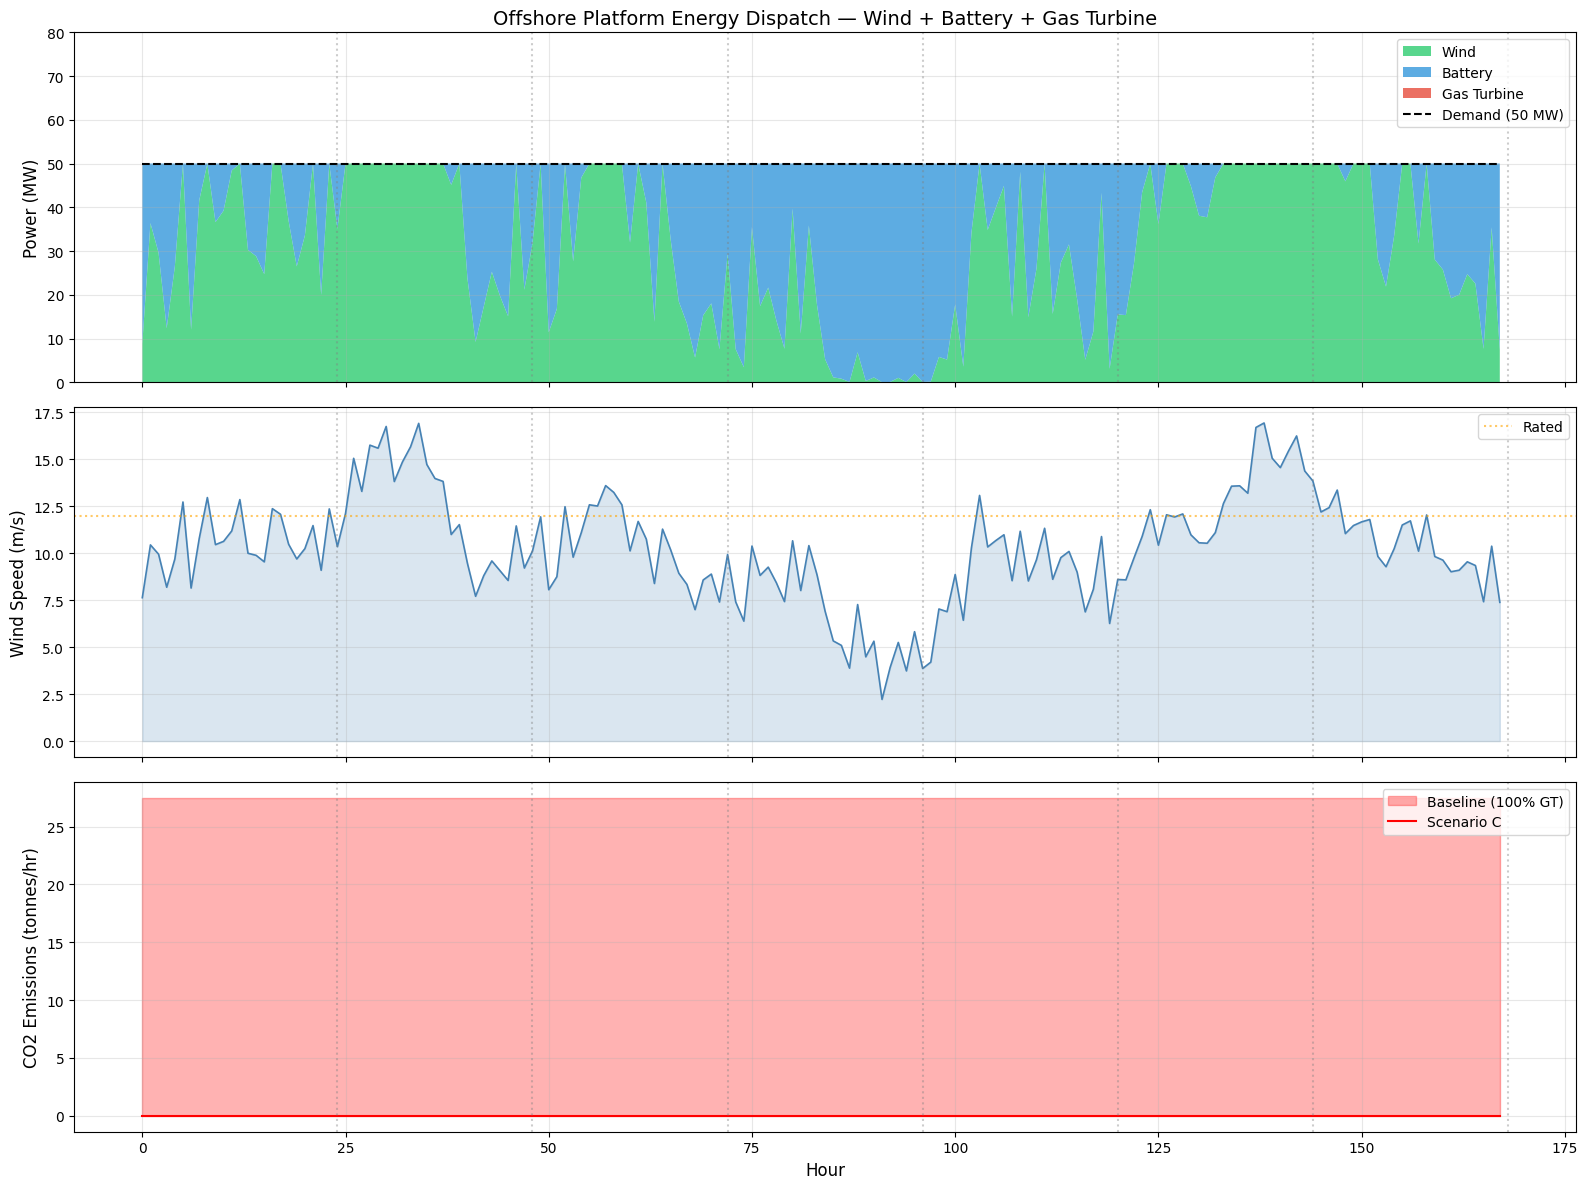

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# --- Power dispatch (stacked) ---
ax = axes[0]
ax.stackplot(t, wind_del_c, batt_del_c, gt_del_c,
             labels=['Wind', 'Battery', 'Gas Turbine'],
             colors=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.8)
ax.plot(t, np.full(hours, 50.0), 'k--', linewidth=1.5, label='Demand (50 MW)')
ax.set_ylabel('Power (MW)', fontsize=12)
ax.set_title('Offshore Platform Energy Dispatch — Wind + Battery + Gas Turbine', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 80)
ax.grid(True, alpha=0.3)

# Add day markers
for d in range(1, 8):
    ax.axvline(x=d*24, color='gray', linestyle=':', alpha=0.4)

# --- Wind speed ---
ax2 = axes[1]
ax2.plot(t, wind_speeds, 'steelblue', linewidth=1.2)
ax2.fill_between(t, wind_speeds, alpha=0.2, color='steelblue')
ax2.axhline(y=12.0, color='orange', linestyle=':', alpha=0.6, label='Rated')
ax2.set_ylabel('Wind Speed (m/s)', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
for d in range(1, 8):
    ax2.axvline(x=d*24, color='gray', linestyle=':', alpha=0.4)

# --- CO2 emissions comparison ---
ax3 = axes[2]
ax3.fill_between(t, baseline_co2_hr * np.ones(hours) / 1000,
                 alpha=0.3, color='red', label='Baseline (100% GT)')
ax3.plot(t, co2_c / 1000, 'r-', linewidth=1.5, label='Scenario C')
ax3.set_xlabel('Hour', fontsize=12)
ax3.set_ylabel('CO2 Emissions (tonnes/hr)', fontsize=12)
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)
for d in range(1, 8):
    ax3.axvline(x=d*24, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

## 7. Scenario Comparison

Compare all three scenarios side by side.

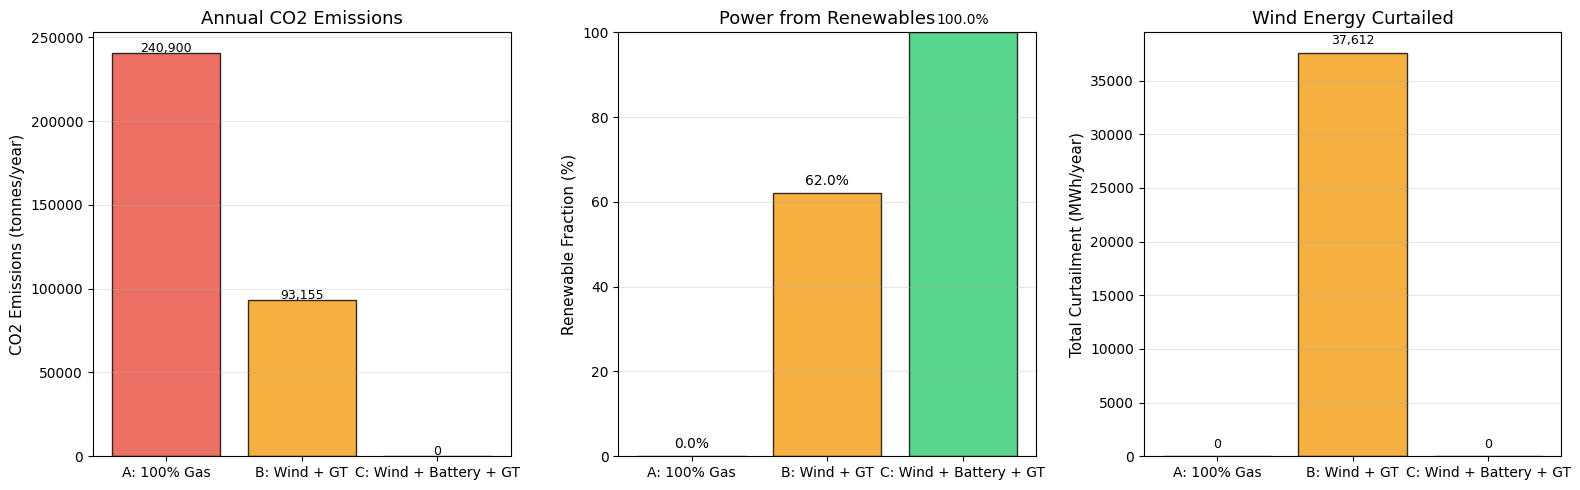

In [9]:
# Compute annualized estimates (scale from 1-week sample)
scale = 8760 / hours

scenarios = ['A: 100% Gas', 'B: Wind + GT', 'C: Wind + Battery + GT']
co2_annual = [
    baseline_co2_year,
    co2_total_b * scale / 1000,
    co2_total_c * scale / 1000,
]
renewable_pct = [0, wind_frac_b, renew_frac_c]
curtailment = [
    0,
    np.sum(curtailed_b) * scale,
    np.sum(curtailed_c) * scale,
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CO2 comparison
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars1 = axes[0].bar(scenarios, co2_annual, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('CO2 Emissions (tonnes/year)', fontsize=11)
axes[0].set_title('Annual CO2 Emissions', fontsize=13)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, co2_annual):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 500,
                f'{val:,.0f}', ha='center', fontsize=9)

# Renewable fraction
bars2 = axes[1].bar(scenarios, renewable_pct, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Renewable Fraction (%)', fontsize=11)
axes[1].set_title('Power from Renewables', fontsize=13)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, renewable_pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2,
                f'{val:.1f}%', ha='center', fontsize=10)

# Curtailment
bars3 = axes[2].bar(scenarios, curtailment, color=colors, alpha=0.8, edgecolor='black')
axes[2].set_ylabel('Total Curtailment (MWh/year)', fontsize=11)
axes[2].set_title('Wind Energy Curtailed', fontsize=13)
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, curtailment):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + max(curtailment)*0.02,
                f'{val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Battery State-of-Charge Analysis

Track battery SOC over the simulation week to understand charge/discharge patterns.

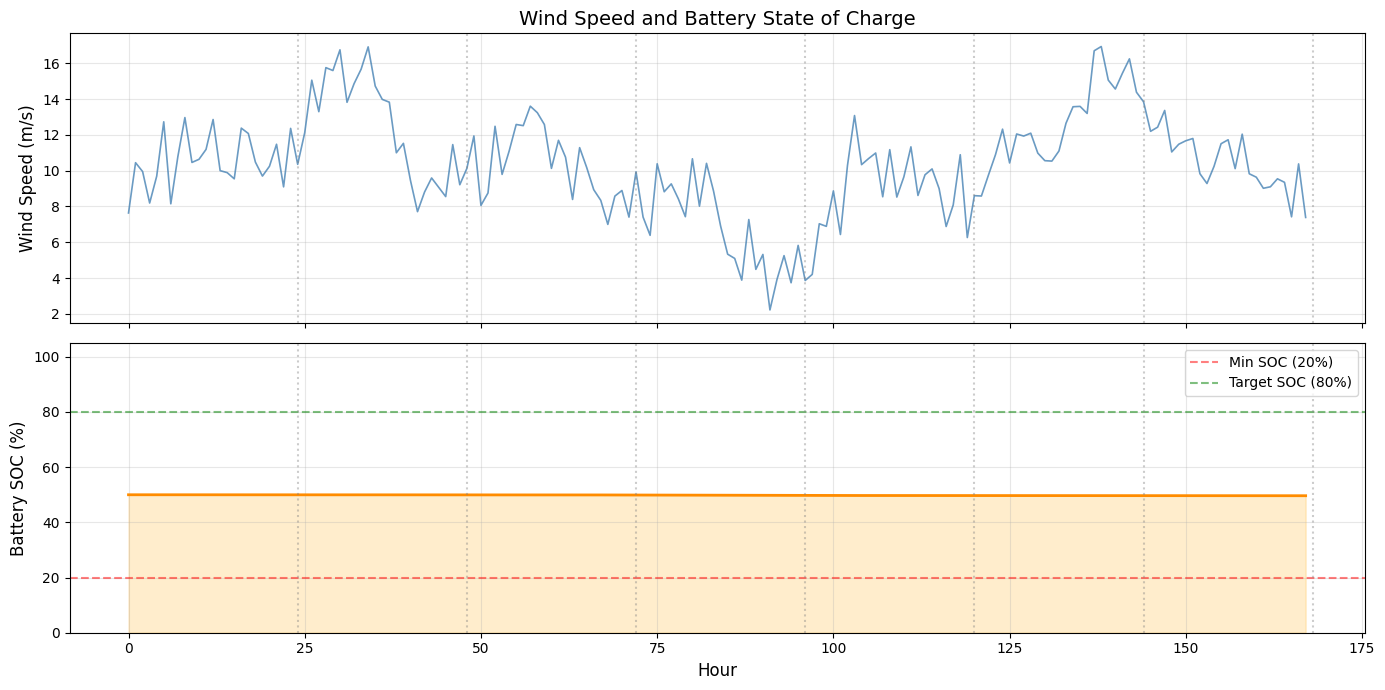

In [10]:
# Re-run Scenario C with SOC tracking
battery_track = BatteryStorage("Battery Track", battery_capacity_j)
battery_track.setStateOfCharge(battery_capacity_j * 0.5)

farm_track = WindFarm("Farm Track", 5)
farm_track.setRatedPowerPerTurbine(15.0e6)
farm_track.setRotorDiameter(236.0)
farm_track.setHubHeight(135.0)
farm_track.setCutInSpeed(3.0)
farm_track.setRatedSpeed(12.0)
farm_track.setCutOutSpeed(25.0)
farm_track.setWakeLossFactor(0.08)
farm_track.setAvailabilityFactor(0.95)
farm_track.setElectricalLossFactor(0.02)
farm_track.setAirTemperature(10.0)

sys_track = OffshoreEnergySystem("Track")
sys_track.setWindFarm(farm_track)
sys_track.setBatteryStorage(battery_track)
sys_track.setGasTurbineCapacity(gt_capacity_w)
sys_track.setGasTurbineEfficiency(gt_efficiency)
sys_track.setGasTurbineMinLoad(gt_min_load)
sys_track.setTotalPowerDemand(platform_demand_w)
sys_track.setCO2EmissionFactor(co2_factor)
sys_track.setTimeStepHours(1.0)

soc_history = [battery_track.getStateOfChargeFraction() * 100]

for i in range(hours):
    farm_track.setWindSpeed(float(wind_speeds[i]))
    sys_track.run()
    soc_history.append(battery_track.getStateOfChargeFraction() * 100)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(t, wind_speeds, 'steelblue', linewidth=1.2, alpha=0.8)
ax1.set_ylabel('Wind Speed (m/s)', fontsize=12)
ax1.set_title('Wind Speed and Battery State of Charge', fontsize=14)
ax1.grid(True, alpha=0.3)

soc_arr = np.array(soc_history[1:])  # Skip initial value
ax2.plot(t, soc_arr, 'darkorange', linewidth=2)
ax2.fill_between(t, soc_arr, alpha=0.2, color='orange')
ax2.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Min SOC (20%)')
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Target SOC (80%)')
ax2.set_xlabel('Hour', fontsize=12)
ax2.set_ylabel('Battery SOC (%)', fontsize=12)
ax2.set_ylim(0, 105)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

for d in range(1, 8):
    ax1.axvline(x=d*24, color='gray', linestyle=':', alpha=0.4)
    ax2.axvline(x=d*24, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

## 9. Battery Size Sensitivity

How does battery capacity affect the renewable fraction and curtailment?

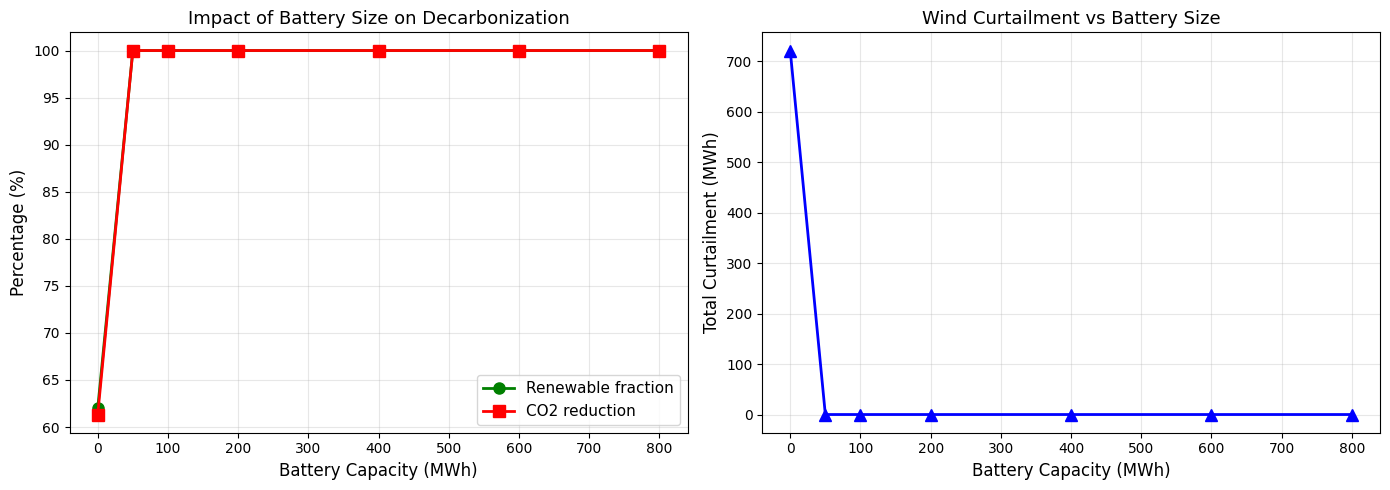

In [11]:
battery_sizes_mwh = [0, 50, 100, 200, 400, 600, 800]
renew_fracs = []
curtailments = []
co2_reductions = []

for size_mwh in battery_sizes_mwh:
    cap_j = size_mwh * 1e6 * 3600.0
    batt_s = BatteryStorage("B", cap_j)
    batt_s.setStateOfCharge(cap_j * 0.5)

    farm_s = WindFarm("F", 5)
    farm_s.setRatedPowerPerTurbine(15.0e6)
    farm_s.setRotorDiameter(236.0)
    farm_s.setHubHeight(135.0)
    farm_s.setCutInSpeed(3.0)
    farm_s.setRatedSpeed(12.0)
    farm_s.setCutOutSpeed(25.0)
    farm_s.setWakeLossFactor(0.08)
    farm_s.setAvailabilityFactor(0.95)
    farm_s.setElectricalLossFactor(0.02)
    farm_s.setAirTemperature(10.0)

    sys_s = OffshoreEnergySystem("S")
    sys_s.setWindFarm(farm_s)
    if size_mwh > 0:
        sys_s.setBatteryStorage(batt_s)
    sys_s.setGasTurbineCapacity(gt_capacity_w)
    sys_s.setGasTurbineEfficiency(gt_efficiency)
    sys_s.setGasTurbineMinLoad(gt_min_load)
    sys_s.setTotalPowerDemand(platform_demand_w)
    sys_s.setCO2EmissionFactor(co2_factor)
    sys_s.setTimeStepHours(1.0)

    wind_java_s = jpype.JArray(jpype.JDouble)(len(wind_speeds))
    for i, v in enumerate(wind_speeds):
        wind_java_s[i] = float(v)
    sys_s.runHourlyDispatch(wind_java_s)

    hist = sys_s.getDispatchHistory()
    w = np.array([float(h.get("windDelivered_MW")) for h in hist])
    b = np.array([float(h.get("batteryDelivered_MW")) for h in hist])
    g = np.array([float(h.get("gasTurbineDelivered_MW")) for h in hist])
    c = np.array([float(h.get("curtailed_MW")) for h in hist])
    co2_s = np.array([float(h.get("co2_kg_hr")) for h in hist])

    total_s = np.sum(w) + np.sum(b) + np.sum(g)
    rf = (np.sum(w) + np.sum(b)) / total_s * 100 if total_s > 0 else 0
    renew_fracs.append(rf)
    curtailments.append(np.sum(c))
    co2_reductions.append((1 - np.sum(co2_s) / (baseline_co2_hr * hours)) * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(battery_sizes_mwh, renew_fracs, 'g-o', markersize=8, linewidth=2, label='Renewable fraction')
ax1.plot(battery_sizes_mwh, co2_reductions, 'r-s', markersize=8, linewidth=2, label='CO2 reduction')
ax1.set_xlabel('Battery Capacity (MWh)', fontsize=12)
ax1.set_ylabel('Percentage (%)', fontsize=12)
ax1.set_title('Impact of Battery Size on Decarbonization', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(battery_sizes_mwh, curtailments, 'b-^', markersize=8, linewidth=2)
ax2.set_xlabel('Battery Capacity (MWh)', fontsize=12)
ax2.set_ylabel('Total Curtailment (MWh)', fontsize=12)
ax2.set_title('Wind Curtailment vs Battery Size', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary

Comparison of all three energy supply scenarios.

In [12]:
print("=" * 75)
print("OFFSHORE PLATFORM ENERGY INTEGRATION — SUMMARY")
print("=" * 75)
print(f"{'Metric':<35} {'A: 100% GT':>12} {'B: Wind+GT':>12} {'C: W+B+GT':>12}")
print("-" * 75)
print(f"{'Wind capacity (MW)':<35} {'0':>12} {'75':>12} {'75':>12}")
print(f"{'Battery capacity (MWh)':<35} {'0':>12} {'0':>12} {'200':>12}")
print(f"{'Gas turbine (MW)':<35} {'50':>12} {'50':>12} {'50':>12}")
print(f"{'Renewable fraction (%)':<35} {'0.0':>12} {wind_frac_b:>12.1f} {renew_frac_c:>12.1f}")
print(f"{'CO2 emissions (t/week)':<35} {baseline_co2_hr*hours/1000:>12.0f} {co2_total_b/1000:>12.1f} {co2_total_c/1000:>12.1f}")
print(f"{'CO2 reduction vs baseline (%)':<35} {'0.0':>12} {co2_saved_b/(baseline_co2_hr*hours)*100:>12.1f} {co2_saved_c/(baseline_co2_hr*hours)*100:>12.1f}")
print(f"{'Curtailment (MWh/week)':<35} {'0.0':>12} {np.sum(curtailed_b):>12.1f} {np.sum(curtailed_c):>12.1f}")
print(f"{'Annual CO2 (tonnes, est.)':<35} {baseline_co2_year:>12,.0f} {co2_total_b*scale/1000:>12,.0f} {co2_total_c*scale/1000:>12,.0f}")
print("=" * 75)
print("\nAll calculations performed using NeqSim's OffshoreEnergySystem class.")
print("Battery enables storing excess wind, reducing both curtailment and CO2 emissions.")

OFFSHORE PLATFORM ENERGY INTEGRATION — SUMMARY
Metric                                A: 100% GT   B: Wind+GT    C: W+B+GT
---------------------------------------------------------------------------
Wind capacity (MW)                             0           75           75
Battery capacity (MWh)                         0            0          200
Gas turbine (MW)                              50           50           50
Renewable fraction (%)                       0.0         62.0        100.0
CO2 emissions (t/week)                      4620       1786.5          0.0
CO2 reduction vs baseline (%)                0.0         61.3        100.0
Curtailment (MWh/week)                       0.0        721.3          0.0
Annual CO2 (tonnes, est.)                240,900       93,155            0

All calculations performed using NeqSim's OffshoreEnergySystem class.
Battery enables storing excess wind, reducing both curtailment and CO2 emissions.
